## Apple stock prediction from 2020-2025

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import os
import numpy as np

## Read CSV file and convert date to datetime 

In [74]:
import pandas as pd

df = pd.read_csv('aapl_us_2025.csv', parse_dates=['Date'])
df = df[(df['Date'] >= '2020-01-01') & (df['Date'] <= '2025-01-17')]
df = df[['Date','Open','High','Low','Close']]
df = df.sort_values('Date').reset_index(drop=True)
df.head()
df.shape

(1269, 5)

## Calculate Mid-price

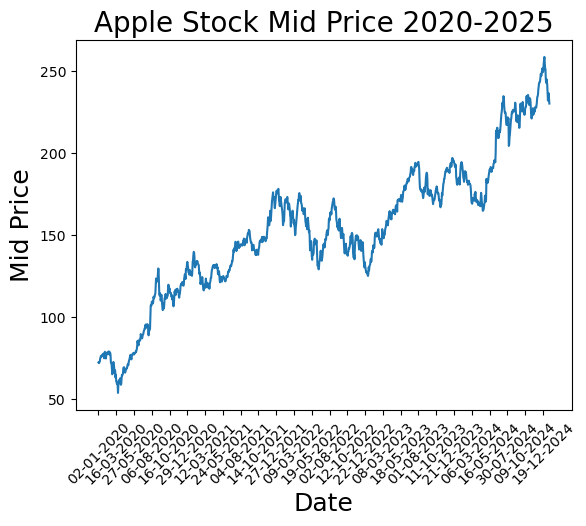

In [75]:
mid_price = (df['High']+df['Low'])/2

plt.plot(range(df.shape[0]), mid_price)
plt.xticks(range(0, df.shape[0], 50), df['Date'].dt.strftime('%d-%m-%Y').loc[::50], rotation=45)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Mid Price', fontsize=18)
plt.title('Apple Stock Mid Price 2020-2025', fontsize=20)
plt.show()

In [76]:
from sklearn.preprocessing import MinMaxScaler

## Normalize the Data 

In [77]:
scaler = MinMaxScaler(feature_range=(0,1)) #Assigns values between 0 to 1 to the data 0 being the lowest and 1 the highest
mid_price_scaled = scaler.fit_transform(mid_price.values.reshape(-1,1))
X, y = [], []
window_size = 60  # past 60 days used to predict next day

## Prepare Input Arrays

In [78]:
for i in range(window_size, len(mid_price_scaled)): #i from 60 to 1269
    X.append(mid_price_scaled[i-window_size:i, 0])  # 60-60 : 59 implies 0:59 days of data and making into 1D array 
    y.append(mid_price_scaled[i, 0]) #60th entry from the 0 to 59 entries of the past 

X, y = np.array(X), np.array(y)


In [79]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1)) #PREPARES X ARRAY FOR LSTM 3D INPUT (#INPUTS, #DAYS , #FEATURES:MID_PRICES)

## Split into train and test data CHRONOLOGICALLY

In [80]:
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

## Build the Model 

The LSTM model was designed with two stacked layers, each containing 70 units, to improve predictions for Apple stock prices. The first LSTM layer captures short-term patterns and daily fluctuations in the data. With return_sequences=True, it outputs the full sequence so the second LSTM layer can learn longer-term trends and summarize broader patterns. Dropout layers, which randomly deactivate 20% of neurons during training, are included after each LSTM to prevent overfitting. Finally, a dense layer produces the predicted next-day mid-price, combining insights from both short-term and long-term temporal patterns learned by the stacked LSTMs.

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1], 1)))
model.add(LSTM(units=70, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=70, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))


## Compile the model

In [82]:

model.compile(optimizer='adam', loss='mean_squared_error') #adaptive moment estimation, adapts the learning rate for each weight individually

## Train model on train set

In [86]:
history = model.fit(X_train, y_train, epochs=25, batch_size=32) 

# epoch is the number of times the model goes through the training set, a very high value could cause over-fitting,
#the batch size splits the data into 32 sets and each set is run through 25 times

Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0016
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0014 
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0013
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0014
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0015
Epoch 6/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0013
Epoch 7/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0013
Epoch 8/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0013
Epoch 9/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0013 
Epoch 10/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0015
Epoch 11/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0014
Epoch 12/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0011
Epoch 13/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0014
Epoch 14/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0012
Epoch 15/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.

## Predict on test set 

In [87]:
predicted = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


## Convert scaled values back to original prices

In [88]:
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1,1))

## Plot Actual price vs Predicted price

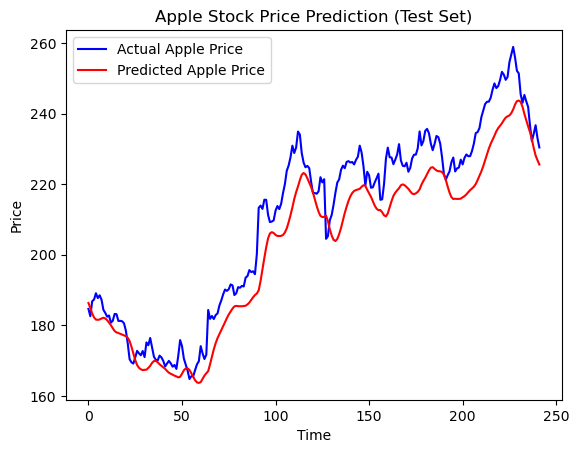

In [89]:
import matplotlib.pyplot as plt

plt.plot(actual_prices, color='blue', label='Actual Apple Price')
plt.plot(predicted_prices, color='red', label='Predicted Apple Price')
plt.title('Apple Stock Price Prediction (Test Set)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

## Plot loss (MSE) of the model over each epoch in training set 

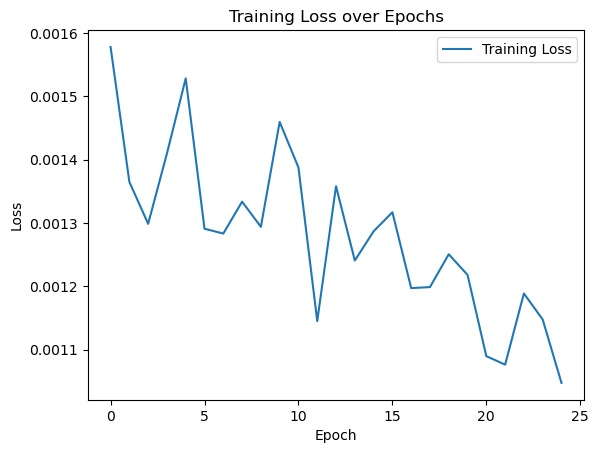

In [90]:
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Conclusion ##
The LSTM model was trained on Apple stock mid-prices from 2020 to 2025, with sequences of 60 days used to predict the next-day price. The training loss graph shows an overall reduction as it captures finer fluctuations. The predicted vs actual price graph demonstrates that the model effectively tracks the overall movement of Apple stock, including recovery patterns after dips, highlighting its ability to learn both short-term and long-term temporal dependencies. This project showcases the application of recurrent neural networks to time-series forecasting, providing a clear example of how deep learning can model and predict complex financial data.